<a href="https://colab.research.google.com/github/aflahbisnis29-commits/uts-bigdata-Aflahul-Aziz-14022300057/blob/main/uts-aflahul-aziz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install google-play-scraper

In [3]:
!pip install google-play-scraper

import os
from google_play_scraper import reviews, Sort
import csv

app_id = 'com.cilegon.simapan'
result, _ = reviews(
    app_id,
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=58,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'
file_path = os.path.join(os.getcwd(), filename)

try:
    with open(file_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
        writer.writeheader()
        for review in result:
            writer.writerow({
                'userName': review['userName'],
                'score': review['score'],
                'at': review['at'],
                'content': review['content']
            })
    print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")
    if os.path.exists(file_path):
        print(f"Verifikasi: File '{filename}' berhasil dibuat di: {file_path}")
    else:
        print(f"Peringatan: File '{filename}' TIDAK DITEMUKAN setelah upaya penyimpanan!")
except Exception as e:
    print(f"Terjadi kesalahan saat menyimpan ulasan ke '{filename}': {e}")

Berhasil menyimpan 58 ulasan ke 'ulasan_google_play.csv'
Verifikasi: File 'ulasan_google_play.csv' berhasil dibuat di: /content/ulasan_google_play.csv


In [4]:
pip install transformers


In [5]:
import pandas as pd
from transformers import pipeline

# Load the CSV file into a pandas DataFrame
df_reviews = pd.read_csv('ulasan_google_play.csv')


# Initialize a sentiment analysis pipeline
# Using a multilingual model that supports Indonesian
sentiment_pipeline = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-sentiment-classifier")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [12]:
# Initialize a sentiment analysis pipeline
# Using a multilingual model that supports Indonesian
sentiment_pipeline = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-sentiment-classifier")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
print(f"DataFrame contains {len(df_reviews)} rows.")
print("Menampilkan 10 baris pertama untuk verifikasi:")
display(df_reviews.head(10))

DataFrame contains 58 rows.
Menampilkan 10 baris pertama untuk verifikasi:


,userName,score,at,content,sentiment,sentiment_score
0,Usaha Seblak,1,2026-03-11 13:59:11,baru di kasih tau sama dewan atau ibu Aulia Ku...,negative,0.999033
1,FA GAMING,5,2026-03-09 15:51:35,terimakasih Cilegon juare sangat sangat memban...,positive,0.991842
2,Marzaqi chanel,2,2026-03-09 04:57:23,ore bise masuk gagal bae,negative,0.998326
3,Warsito,5,2026-03-09 01:42:41,"Apk nya cukup bagus, cuman sayang hampura bang...",negative,0.904890
4,Siswan Toro,2,2026-03-09 00:01:58,blm bisa log in... udah masuk KTP n WA email b...,neutral,0.831736
5,yayuk,1,2026-03-08 22:22:51,gjelas bnget ni aplikasi suruh masukin passwor...,negative,0.919179
6,Leo Oppo,5,2026-03-08 22:20:25,tolong dong pas daftar di menu untuk isi data ...,negative,0.988698
7,Herlin Eka,2,2026-03-08 21:43:00,aplikasi APA ini susah amat mau login daftar n...,negative,0.998651
8,Ayi ndis,4,2026-03-08 17:23:37,"login nya lumayan susah, error system",negative,0.993753
9,Umi Kulsum,5,2026-03-06 09:55:56,keren,positive,0.993960


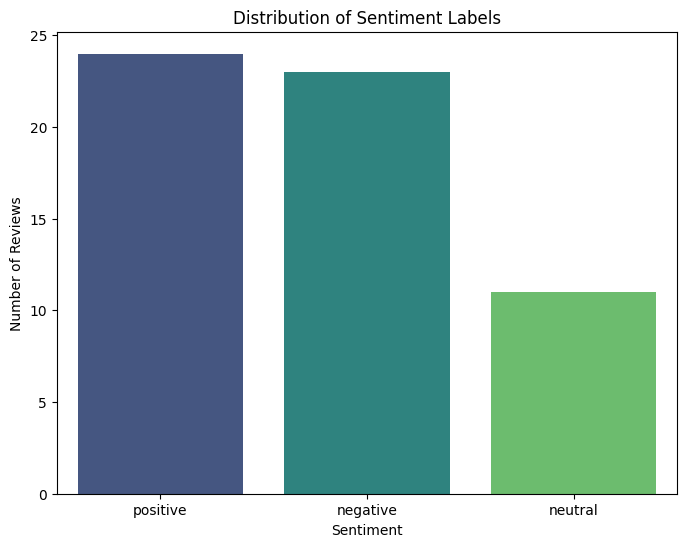

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- FIX: Apply sentiment analysis to create the 'sentiment' column ---
df_reviews['sentiment'] = df_reviews['content'].apply(lambda x: sentiment_pipeline(x)[0]['label'])
df_reviews['sentiment_score'] = df_reviews['content'].apply(lambda x: sentiment_pipeline(x)[0]['score'])
# ----------------------------------------------------------------------

# Calculate the distribution of sentiment labels
sentiment_counts = df_reviews['sentiment'].value_counts()

# Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis', hue=sentiment_counts.index, legend=False)
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()
